# Interpolation using kriging in one time step

In [1]:
import xarray as xr
import numpy as np
import scipy
from matplotlib import pyplot as plt

In [2]:
data_input = scipy.io.loadmat("./depsi_matlab_atmo_kriging_testdata/zegveld_s1_t037_ps_atmo_kriging_input.mat")
ds = xr.Dataset(
    {
        "ps_atmosphere": (["space", "time"], data_input["atmo_estimates"])
    },
    coords={
        "x": ("space", data_input["psc_azx"].squeeze()),
        "y": ("space", data_input["psc_rx"].squeeze()),
    }
)

In [3]:
# select one time step
da = ds["ps_atmosphere"].isel(time=1)

## Inspect the variogram cloud

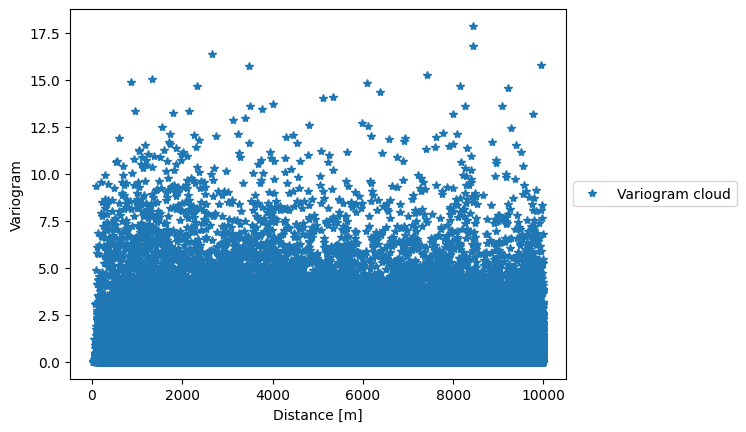

In [4]:
from depsi.atmosphere_estimation import calculate_variogram_cloud

distances, variogram_cloud = calculate_variogram_cloud(da, cutoff=10000.0) # cutoff=10000.0 is default

# plot
fig, ax = plt.subplots() 
ax.plot(distances, variogram_cloud, '*', label = 'Variogram cloud')

ax.set_xlabel('Distance [m]')
ax.set_ylabel('Variogram')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

plt.show()

## Estimate an empirical variogram

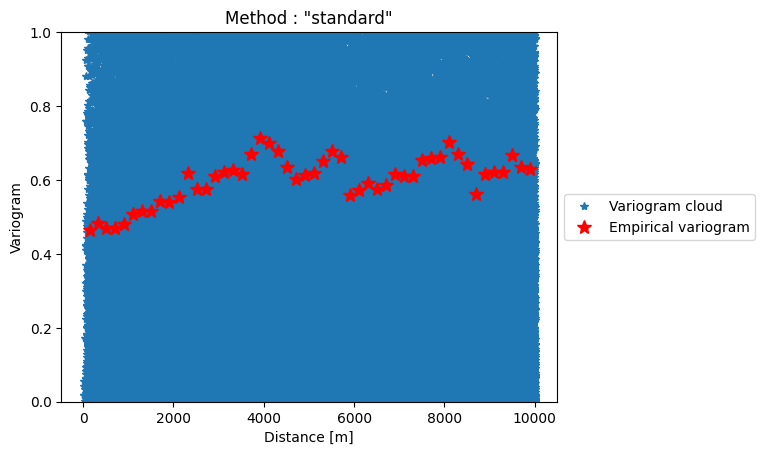

In [5]:
from depsi.atmosphere_estimation import calculate_empirical_variogram

lags, semivariances = calculate_empirical_variogram(
    da,
    method= "standard", # This is default,  Options are:'standard', 'unbiased', 'unbiased_robust'
    nlags= 50, # This is default
    cutoff=10000.0, # This is default
)

# Plot
fig, ax = plt.subplots() 
ax.plot(distances, variogram_cloud, '*', label = 'Variogram cloud')
ax.plot(lags, semivariances, 'r*', markersize=10, label = 'Empirical variogram')

ax.set_xlabel('Distance [m]')
ax.set_ylabel('Variogram')
ax.set_ylim(bottom=0, top=1)

plt.title('Method : "standard"')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Move legend outside

plt.show()

## Fit a variogram model

{'sill': np.float64(0.6333732657458974), 'range': np.float64(3589.7480713564155), 'nugget': np.float64(0.45789040071547593)}


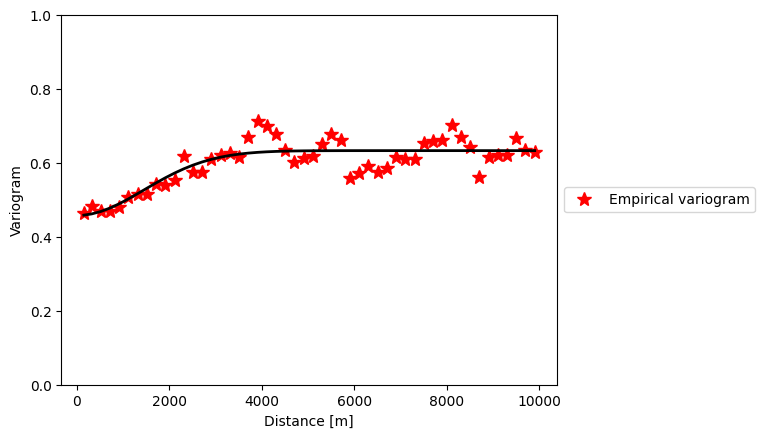

In [8]:
from depsi.atmosphere_estimation import fit_variogram

etimated_model_parameters, lag_variances = fit_variogram(
    da,
    variogram_model="gaussian",  # This is default, Options are: 'linear', 'power', 'gaussian', 'spherical', 'exponential', 'hole-effect'
    empirical_variogram_method="standard",
    empirical_variogram_nlags=50,
    empirical_variogram_cutoff=10000.0,
)

lags, estimated_semivariances, empirical_semivariances = lag_variances

# print
print(etimated_model_parameters)

# plot
fig, ax = plt.subplots() 
ax.plot(lags, empirical_semivariances, 'r*', markersize=10, label = 'Empirical variogram')
ax.plot(lags, estimated_semivariances, 'black', linewidth=2)

ax.set_xlabel('Distance [m]')
ax.set_ylabel('Variogram')
ax.set_ylim(bottom=0, top=1)


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))  # Move legend outside

plt.show()

## Set up kriging system

In [9]:
from depsi.atmosphere_estimation import setup_kriging_system

krige_obj = setup_kriging_system(
    da,
    method='universal', # this is default
    variogram_args={
    "variogram_model": "gaussian",
    "variogram_parameters": etimated_model_parameters,
    "drift_terms": "regional_linear" #  drift of order 1
    }    
)

In [10]:
krige_obj.variogram_model_parameters

[np.float64(0.17548286503042143),
 np.float64(3589.7480713564155),
 np.float64(0.45789040071547593)]

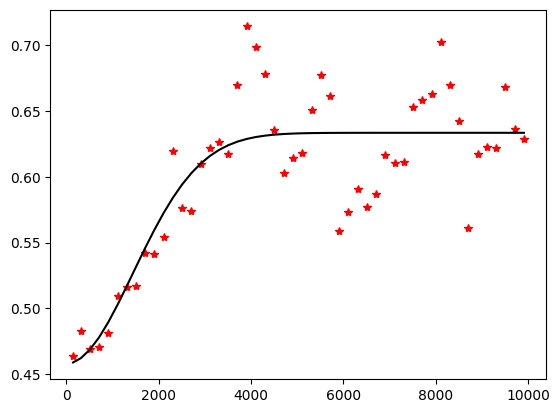

In [11]:
krige_obj.display_variogram_model()

In [12]:
# variogram model goodness of fit statistcs
print(
    krige_obj.Q1,  # mean of standardized residuals (should ≈ 0)
    krige_obj.Q2,  # mean squared standardized residuals (should ≈ 1)
    krige_obj.cR  # coefficient of model reliability/fit (lower = better)
)

0.002384657145811475 0.5631403774814568 0.28437441712330946


## Solve kriging system for observation points

In [13]:
from depsi.atmosphere_estimation import solve_kriging_per_single_time

points = xr.Dataset(coords = da.coords)  # prediction points

In [14]:
kwrgs_variogram_model = {
    "variogram_model": "gaussian",
    "variogram_parameters": etimated_model_parameters,
    "drift_terms": "regional_linear" #  drift of order 1
}

zvalues, sigmasq = solve_kriging_per_single_time(
    da,
    grid=points,
    method="universal",
    n_nearest_neighbors=100,
    variogram_args={
    "variogram_model": "gaussian",
    "variogram_parameters": etimated_model_parameters,
    "drift_terms": "regional_linear" #  drift of order 1
    }    
)

Another way of running the function with default values

In [15]:
%%time
# Universal kriging with drift term of order 1
zvalues, sigmasq  = solve_kriging_per_single_time(da, grid=points, n_nearest_neighbors=100)

CPU times: user 7.4 s, sys: 738 ms, total: 8.14 s
Wall time: 4.04 s


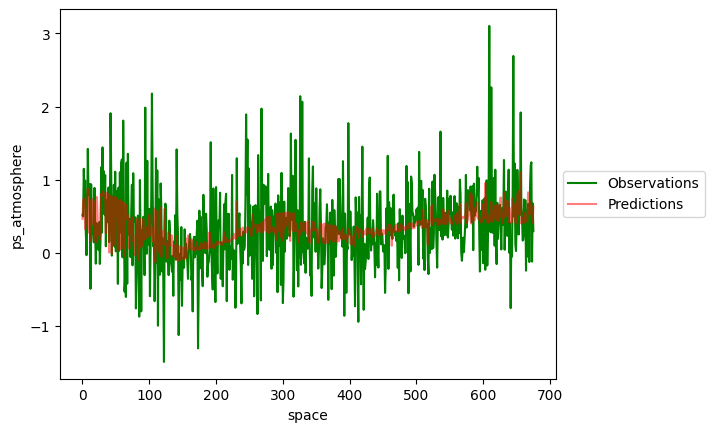

In [16]:
# plot 
da.plot(color="green", label="Observations")
plt.plot(zvalues,color="red", alpha=0.5, label="Predictions")

plt.legend(["Observations", "Predictions"], loc='center left', bbox_to_anchor=(1, 0.5))  # Move legend outside

plt.show()

## Solve kriging system for observation points on sparse grid

In [17]:
from depsi.atmosphere_estimation import solve_kriging_per_single_time

# create a grid with size 100 meter
x_min, x_max = da.x.min(), da.x.max()
y_min, y_max = da.y.min(), da.y.max()

grid_resolution = 100 # in meter
x_grid = np.arange(x_min, x_max + grid_resolution, grid_resolution)
y_grid = np.arange(y_min, y_max + grid_resolution, grid_resolution)
grid = xr.Dataset(coords={"x": x_grid, "y": y_grid})

In [18]:
# Find closest grid coords for each point of observations
x_closest = []
y_closest = []
for px, py in zip(da.coords["x"], da.coords["y"]):
    sel = grid.sel(x=px, y=py, method="nearest")
    x_closest.append(float(sel.x))
    y_closest.append(float(sel.y))

points = xr.Dataset(coords={"x": ("space", x_closest) , "y": ("space", y_closest)})  # prediction points

In [19]:
# do kriging on those grid points
zvalues, sigmasq  = solve_kriging_per_single_time(da, grid=points, n_nearest_neighbors=100)
points["predictions"] = ("space", zvalues)

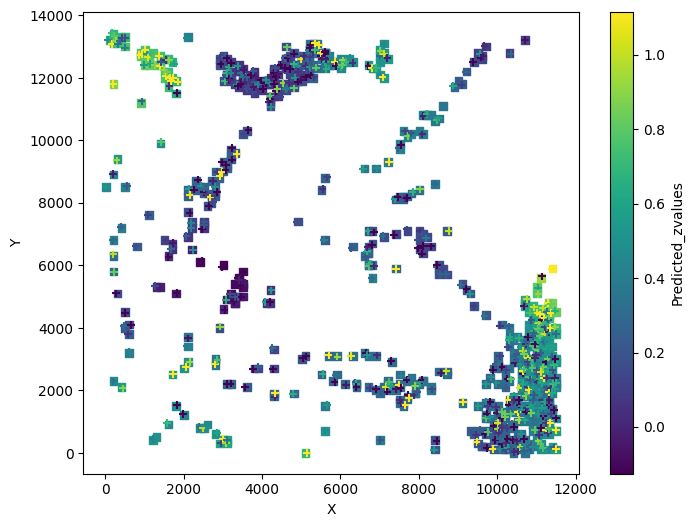

In [20]:
vmin, vmax = points["predictions"].min(), points["predictions"].max()

plt.figure(figsize=(8,6))

plt.scatter(points["predictions"].x, points["predictions"].y, c=points["predictions"].values, s=30, cmap="viridis", marker="s", vmin=vmin, vmax=vmax)
plt.scatter(da.x, da.y, c=da.values, s=30, cmap="viridis", marker="+", vmin=vmin, vmax=vmax)
plt.colorbar(label='Predicted_zvalues')

plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## Solve kriging system for grid

In [21]:
from depsi.atmosphere_estimation import solve_kriging_per_single_time

# create a grid with size 500 meter
x_min, x_max = da.x.min(), da.x.max()
y_min, y_max = da.y.min(), da.y.max()

grid_resolution = 500 # in meter
x_grid = np.arange(x_min, x_max + grid_resolution, grid_resolution)
y_grid = np.arange(y_min, y_max + grid_resolution, grid_resolution)
grid = xr.Dataset(coords={"x": x_grid, "y": y_grid})

In [22]:
%%time
# Universal kriging with drift term of order 1
# NOTE: n_nearest_neighbors cannot be set when interpolating on a grid. 
zvalues, sigmasq  = solve_kriging_per_single_time(da, grid=grid)

CPU times: user 3.14 s, sys: 17.6 ms, total: 3.16 s
Wall time: 2.57 s


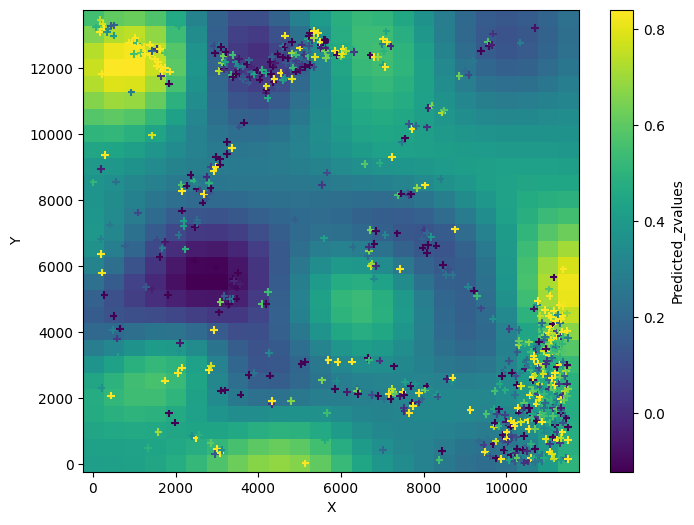

In [23]:
# plot
# add results to the dataset for plotting
grid["zvalues"] = (("y", "x"), zvalues)
grid["sigmasq"] = (("y", "x"), sigmasq)

vmin, vmax = grid["zvalues"].min(), grid["zvalues"].max()

plt.figure(figsize=(8,6))
plt.pcolormesh(grid.x, grid.y, grid.zvalues, shading='nearest', cmap='viridis', vmin=vmin, vmax=vmax)
plt.colorbar(label='Predicted_zvalues')

plt.scatter(da.x, da.y, c=da.values, s=30, cmap="viridis", marker="+", vmin=vmin, vmax=vmax)
plt.xlabel("X")
plt.ylabel("Y")
plt.show()